In [ ]:
# ==========================================
# STEP 1: Install Required Packages
# ==========================================

# Install RDKit (if not already installed)
!pip install rdkit-pypi

# Install additional visualization packages
!pip install seaborn matplotlib plotly kaleido

🧬 RDKit EMBEDDING FAILURE DETECTOR
This tool identifies compounds that fail RDKit processing
(the 'Embedding failed' type errors you mentioned)
Please upload your CSV file containing 'compound_name' and 'smiles' columns:


Saving diverse_representatives.csv to diverse_representatives.csv
File 'diverse_representatives.csv' uploaded successfully!
Dataset shape: (228, 6)
Columns: ['cluster_id', 'compound_idx', 'compound_name', 'smiles', 'cluster_size', 'selection_method']

First 5 rows:
   cluster_id  compound_idx compound_name  \
0           0          2816     NPC-61059   
1           0          1515     NPC-17446   
2           0          2127     NPC-38778   
3           1          2181     NPC-40664   
4           1           978       NPC-644   

                                              smiles  cluster_size  \
0                      CC1(CCCC2(C13CC3C(=C)C=C2)C)C           586   
1             CC(C)C(=O)OCC(C)C(C(C)(C)C)OC(=O)C(C)C           586   
2         c1cc(ccc1[C@@H]([C@H](c1cc(cc(c1)O)O)O)O)O           586   
3  CC(=O)O[C@@H]([C@H]1CC[C@]2([C@]1(C)CC[C@H]1[C...           452   
4                           CNCCc1c[nH]c2c1cc(OC)cc2           452   

    selection_method  
0  diverse_selectio

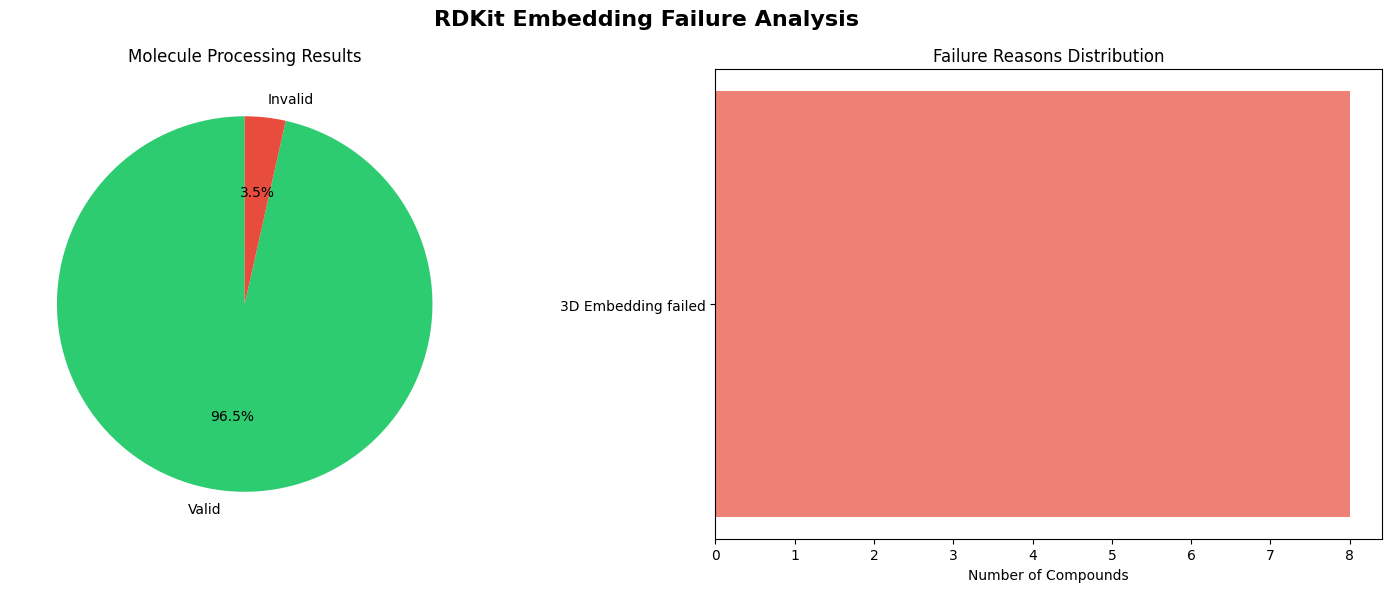

📝 Generating summary report...

RDKit EMBEDDING FAILURE ANALYSIS REPORT

DATASET OVERVIEW:
- Total compounds processed: 228
- Valid compounds: 220 (96.5%)
- Invalid compounds: 8 (3.5%)

VALIDATION STEPS PERFORMED:
1. SMILES parsing with RDKit
2. Hydrogen addition
3. 3D structure embedding
4. Molecular optimization

FAILURE BREAKDOWN:
- 3D Embedding failed: 8 compounds (100.0% of invalid)

FAILED COMPOUNDS (first 10):
- NPC-82348
- NPC-57724
- NPC-52553
- NPC-69070
- NPC-93149
- NPC-84814
- NPC-83350
- NPC-83027

💾 Saving results...

🎉 ANALYSIS COMPLETE!
Files generated:
   📄 embedding_test_results.csv - Complete results
   📄 valid_compounds_only.csv - Only valid compounds (embedding failures removed)
   📄 invalid_compounds_removed.csv - Compounds that failed embedding
   📄 embedding_failure_report.txt - Detailed analysis report
   📊 embedding_failure_analysis.png - Visualization

✨ Use 'valid_compounds_only.csv' for your docking studies!
   This file contains only compounds that passed

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from google.colab import files
import io
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

class EmbeddingFilter:
    """
    A focused molecular filter that removes only compounds that fail RDKit processing/embedding
    """

    def __init__(self):
        self.failed_compounds = []
        self.failure_reasons = []

    def test_molecule_validity(self, smiles):
        """
        Test if a molecule can be properly processed by RDKit
        Returns: (is_valid, failure_reason)
        """
        try:
            # Step 1: Parse SMILES
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return False, "Invalid SMILES - Cannot parse"

            # Step 2: Add hydrogens
            mol_with_hs = Chem.AddHs(mol)
            if mol_with_hs is None:
                return False, "Cannot add hydrogens"

            # Step 3: Test 3D embedding (this is where most "Embedding failed" errors occur)
            result = AllChem.EmbedMolecule(mol_with_hs, randomSeed=42)
            if result != 0:
                return False, "3D Embedding failed"

            # Step 4: Test optimization
            try:
                AllChem.MMFFOptimizeMolecule(mol_with_hs)
            except:
                return False, "Optimization failed"

            # If we get here, the molecule is valid for docking
            return True, "Valid"

        except Exception as e:
            return False, f"Processing error: {str(e)[:50]}"

    def process_dataframe(self, df):
        """Process the entire dataframe and filter out embedding failures"""
        print("Testing molecules for RDKit processing compatibility...")
        print("This checks: SMILES parsing → H addition → 3D embedding → optimization")
        print("-" * 70)

        # Initialize result columns
        df['Status'] = 'Unknown'
        df['Failure_Reason'] = ''

        valid_count = 0
        invalid_count = 0

        for idx, row in df.iterrows():
            smiles = row['smiles']
            is_valid, reason = self.test_molecule_validity(smiles)

            if is_valid:
                df.at[idx, 'Status'] = 'Valid'
                df.at[idx, 'Failure_Reason'] = 'Passed all tests'
                valid_count += 1
            else:
                df.at[idx, 'Status'] = 'Invalid'
                df.at[idx, 'Failure_Reason'] = reason
                invalid_count += 1
                self.failed_compounds.append(row['compound_name'])
                self.failure_reasons.append(reason)

            # Progress update
            if (idx + 1) % 50 == 0:
                print(f"Processed {idx + 1}/{len(df)} molecules... "
                      f"Valid: {valid_count}, Invalid: {invalid_count}")

        print(f"\n✅ Processing complete!")
        print(f"Valid molecules: {valid_count}")
        print(f"Invalid molecules: {invalid_count}")

        return df

def upload_and_read_csv():
    """Handle CSV file upload and reading"""
    print("Please upload your CSV file containing 'compound_name' and 'smiles' columns:")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded!")
        return None

    filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    print(f"File '{filename}' uploaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

    # Check required columns
    required_cols = ['compound_name', 'smiles']
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"ERROR: Missing required columns: {missing_cols}")
        print("Your CSV must contain 'compound_name' and 'smiles' columns")
        return None

    print(f"\nFirst 5 rows:")
    print(df.head())

    return df

def create_failure_analysis(df, filter_obj):
    """Create visualizations showing failure analysis"""
    plt.style.use('default')
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('RDKit Embedding Failure Analysis', fontsize=16, fontweight='bold')

    # 1. Overall valid/invalid pie chart
    status_counts = df['Status'].value_counts()
    colors = ['#2ecc71', '#e74c3c']

    axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[0].set_title('Molecule Processing Results')

    # 2. Failure reasons breakdown
    if filter_obj.failure_reasons:
        reason_counts = Counter(filter_obj.failure_reasons)
        reasons = list(reason_counts.keys())
        counts = list(reason_counts.values())

        axes[1].barh(reasons, counts, color='#e74c3c', alpha=0.7)
        axes[1].set_title('Failure Reasons Distribution')
        axes[1].set_xlabel('Number of Compounds')

        # Adjust text size if many reasons
        if len(reasons) > 8:
            axes[1].tick_params(axis='y', labelsize=9)
    else:
        axes[1].text(0.5, 0.5, 'No Failures!\nAll molecules are valid',
                     ha='center', va='center', transform=axes[1].transAxes,
                     fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
        axes[1].set_title('Failure Reasons Distribution')

    plt.tight_layout()
    plt.savefig('embedding_failure_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def generate_summary_report(df, filter_obj):
    """Generate a summary report"""
    total_compounds = len(df)
    valid_compounds = len(df[df['Status'] == 'Valid'])
    invalid_compounds = len(df[df['Status'] == 'Invalid'])

    report = f"""
RDKit EMBEDDING FAILURE ANALYSIS REPORT
{'='*50}

DATASET OVERVIEW:
- Total compounds processed: {total_compounds}
- Valid compounds: {valid_compounds} ({valid_compounds/total_compounds*100:.1f}%)
- Invalid compounds: {invalid_compounds} ({invalid_compounds/total_compounds*100:.1f}%)

VALIDATION STEPS PERFORMED:
1. SMILES parsing with RDKit
2. Hydrogen addition
3. 3D structure embedding
4. Molecular optimization

FAILURE BREAKDOWN:
"""

    if filter_obj.failure_reasons:
        reason_counts = Counter(filter_obj.failure_reasons)
        for reason, count in reason_counts.most_common():
            percentage = (count / invalid_compounds) * 100 if invalid_compounds > 0 else 0
            report += f"- {reason}: {count} compounds ({percentage:.1f}% of invalid)\n"
    else:
        report += "- No failures detected! All molecules are valid for docking.\n"

    if invalid_compounds > 0:
        report += f"\nFAILED COMPOUNDS (first 10):\n"
        for i, compound in enumerate(filter_obj.failed_compounds[:10]):
            report += f"- {compound}\n"
        if len(filter_obj.failed_compounds) > 10:
            report += f"... and {len(filter_obj.failed_compounds) - 10} more\n"

    return report

def main():
    """Main execution function"""
    print("🧬 RDKit EMBEDDING FAILURE DETECTOR")
    print("=" * 50)
    print("This tool identifies compounds that fail RDKit processing")
    print("(the 'Embedding failed' type errors you mentioned)")
    print("=" * 50)

    # Step 1: Upload and read CSV
    df = upload_and_read_csv()
    if df is None:
        return

    # Step 2: Initialize filter and test molecules
    embedding_filter = EmbeddingFilter()
    processed_df = embedding_filter.process_dataframe(df)

    # Step 3: Generate visualizations
    print(f"\n📈 Generating failure analysis...")
    create_failure_analysis(processed_df, embedding_filter)

    # Step 4: Generate summary report
    print(f"📝 Generating summary report...")
    summary_report = generate_summary_report(processed_df, embedding_filter)

    with open('embedding_failure_report.txt', 'w') as f:
        f.write(summary_report)

    print(summary_report)

    # Step 5: Save results
    print(f"💾 Saving results...")

    # Save full results
    processed_df.to_csv('embedding_test_results.csv', index=False)

    # Save only VALID compounds (remove embedding failures)
    valid_df = processed_df[processed_df['Status'] == 'Valid']
    valid_df.to_csv('valid_compounds_only.csv', index=False)

    # Save only INVALID compounds for review
    invalid_df = processed_df[processed_df['Status'] == 'Invalid']
    if len(invalid_df) > 0:
        invalid_df.to_csv('invalid_compounds_removed.csv', index=False)

    print(f"\n🎉 ANALYSIS COMPLETE!")
    print(f"Files generated:")
    print(f"   📄 embedding_test_results.csv - Complete results")
    print(f"   📄 valid_compounds_only.csv - Only valid compounds (embedding failures removed)")
    if len(invalid_df) > 0:
        print(f"   📄 invalid_compounds_removed.csv - Compounds that failed embedding")
    print(f"   📄 embedding_failure_report.txt - Detailed analysis report")
    print(f"   📊 embedding_failure_analysis.png - Visualization")
    '''
    # Download files
    print(f"\n⬇️  Downloading files...")
    files.download('embedding_test_results.csv')
    files.download('valid_compounds_only.csv')
    if len(invalid_df) > 0:
        files.download('invalid_compounds_removed.csv')
    files.download('embedding_failure_report.txt')
    files.download('embedding_failure_analysis.png')
    '''
    print(f"\n✨ Use 'valid_compounds_only.csv' for your docking studies!")
    print(f"   This file contains only compounds that passed RDKit processing.")

# Install required packages (run this first in Colab)
# !pip install rdkit-pypi pandas matplotlib numpy

# Run the main pipeline
if __name__ == "__main__":
    main()

In [ ]:
# prompt: download all result and visualization in zip files

import zipfile
import os

# Create a zip file containing results and visualizations
# Correcting filenames to match the actual output from the previous cell
with zipfile.ZipFile('embedding_analysis_results_and_viz.zip', 'w') as zipf:
    # Add results files
    zipf.write('embedding_test_results.csv')
    zipf.write('valid_compounds_only.csv')
    # Check if invalid_compounds_removed.csv exists before adding
    if os.path.exists('invalid_compounds_removed.csv'):
        zipf.write('invalid_compounds_removed.csv')
    zipf.write('embedding_failure_report.txt')
    # Add visualization file
    zipf.write('embedding_failure_analysis.png')

print("Created embedding_analysis_results_and_viz.zip")

# Download the zip files
print("\n⬇️  Downloading zip files...")
files.download('embedding_analysis_results_and_viz.zip')

print("\nZip files downloaded!")

# The first zip creation block is removed as the filenames were incorrect
# and only one zip file containing the embedding analysis results was mentioned
# and created with the correct filenames in the second block.

Created embedding_analysis_results_and_viz.zip

⬇️  Downloading zip files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Zip files downloaded!
